# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/guriya79/mental-health-disorder/mental_health_risk_dataset (1).csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/guriya79/mental-health-disorder/mental_health_risk_dataset (1).csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.1,14.1,7.2,10,5,...,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.0,0.5,10.3,2,10,...,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0


## last Five row

In [4]:
df.tail()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
24995,36,Female,Single,Bachelor,Unemployed,3.3,8.4,4.6,4,3,...,1,2,5,1,0,0,1,0,0,0
24996,49,Female,Divorced,Master,Student,4.7,6.6,2.1,6,6,...,2,8,7,1,1,0,0,0,1,1
24997,35,Female,Married,PhD,Self-Employed,4.0,12.8,11.3,4,10,...,7,3,3,4,1,0,1,0,1,2
24998,44,Male,Divorced,High School,Student,5.1,2.0,3.0,5,4,...,7,7,8,1,0,1,1,0,1,0
24999,19,Male,Single,Master,Self-Employed,9.4,14.3,11.8,10,1,...,9,3,5,1,1,0,1,0,1,1


## Shape of our dataset

In [5]:
df.shape

(25000, 25)

## List out all columns

In [6]:
df.columns

Index(['age', 'gender', 'marital_status', 'education_level',
       'employment_status', 'sleep_hours', 'physical_activity_hours_per_week',
       'screen_time_hours_per_day', 'social_support_score',
       'work_stress_level', 'academic_pressure_level',
       'job_satisfaction_score', 'financial_stress_level',
       'working_hours_per_week', 'anxiety_score', 'depression_score',
       'stress_level', 'mood_swings_frequency',
       'concentration_difficulty_level', 'panic_attack_history',
       'family_history_mental_illness', 'previous_mental_health_diagnosis',
       'therapy_history', 'substance_use', 'mental_health_risk'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

age                                   int64
gender                               object
marital_status                       object
education_level                      object
employment_status                    object
sleep_hours                         float64
physical_activity_hours_per_week    float64
screen_time_hours_per_day           float64
social_support_score                  int64
work_stress_level                     int64
academic_pressure_level               int64
job_satisfaction_score                int64
financial_stress_level                int64
working_hours_per_week                int64
anxiety_score                         int64
depression_score                      int64
stress_level                          int64
mood_swings_frequency                 int64
concentration_difficulty_level        int64
panic_attack_history                  int64
family_history_mental_illness         int64
previous_mental_health_diagnosis      int64
therapy_history                 

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               25000 non-null  int64  
 1   gender                            25000 non-null  object 
 2   marital_status                    25000 non-null  object 
 3   education_level                   25000 non-null  object 
 4   employment_status                 25000 non-null  object 
 5   sleep_hours                       25000 non-null  float64
 6   physical_activity_hours_per_week  25000 non-null  float64
 7   screen_time_hours_per_day         25000 non-null  float64
 8   social_support_score              25000 non-null  int64  
 9   work_stress_level                 25000 non-null  int64  
 10  academic_pressure_level           25000 non-null  int64  
 11  job_satisfaction_score            25000 non-null  int64  
 12  fina

## Check Null Value

In [9]:
df.isnull().sum()

age                                 0
gender                              0
marital_status                      0
education_level                     0
employment_status                   0
sleep_hours                         0
physical_activity_hours_per_week    0
screen_time_hours_per_day           0
social_support_score                0
work_stress_level                   0
academic_pressure_level             0
job_satisfaction_score              0
financial_stress_level              0
working_hours_per_week              0
anxiety_score                       0
depression_score                    0
stress_level                        0
mood_swings_frequency               0
concentration_difficulty_level      0
panic_attack_history                0
family_history_mental_illness       0
previous_mental_health_diagnosis    0
therapy_history                     0
substance_use                       0
mental_health_risk                  0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,age,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,39.072560,6.509516,7.515400,6.469132,5.50840,5.517080,5.445880,5.471040,5.495080,45.049600,...,5.534000,5.520480,5.512880,5.488240,0.497840,0.504280,0.504160,0.501640,0.499120,0.778520
std,12.404948,2.015586,4.324346,3.167682,2.88694,2.864548,2.864479,2.867816,2.881636,14.683297,...,2.870048,2.873213,2.870596,2.873178,0.500005,0.499992,0.499993,0.500007,0.500009,0.691409
min,18.000000,3.000000,0.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,20.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,4.800000,3.800000,3.700000,3.00000,3.000000,3.000000,3.000000,3.000000,32.000000,...,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,6.500000,7.500000,6.500000,5.00000,6.000000,5.000000,5.000000,5.000000,45.000000,...,6.000000,6.000000,6.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
75%,50.000000,8.200000,11.300000,9.200000,8.00000,8.000000,8.000000,8.000000,8.000000,58.000000,...,8.000000,8.000000,8.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,60.000000,10.000000,15.000000,12.000000,10.00000,10.000000,10.000000,10.000000,10.000000,70.000000,...,10.000000,10.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

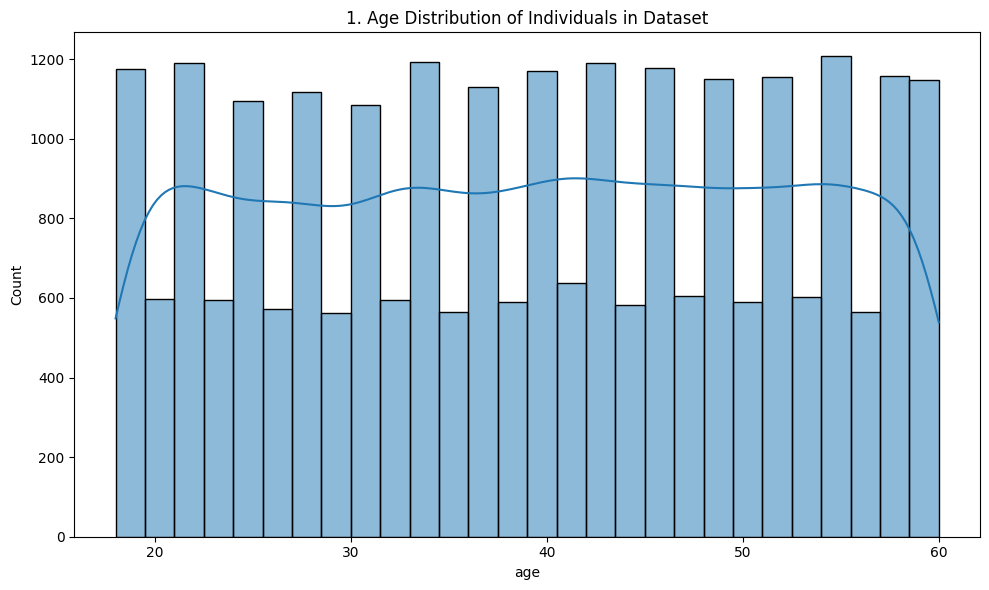

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True)
plt.title(f'{plot_no}. Age Distribution of Individuals in Dataset')
show_fig()
plot_no += 1

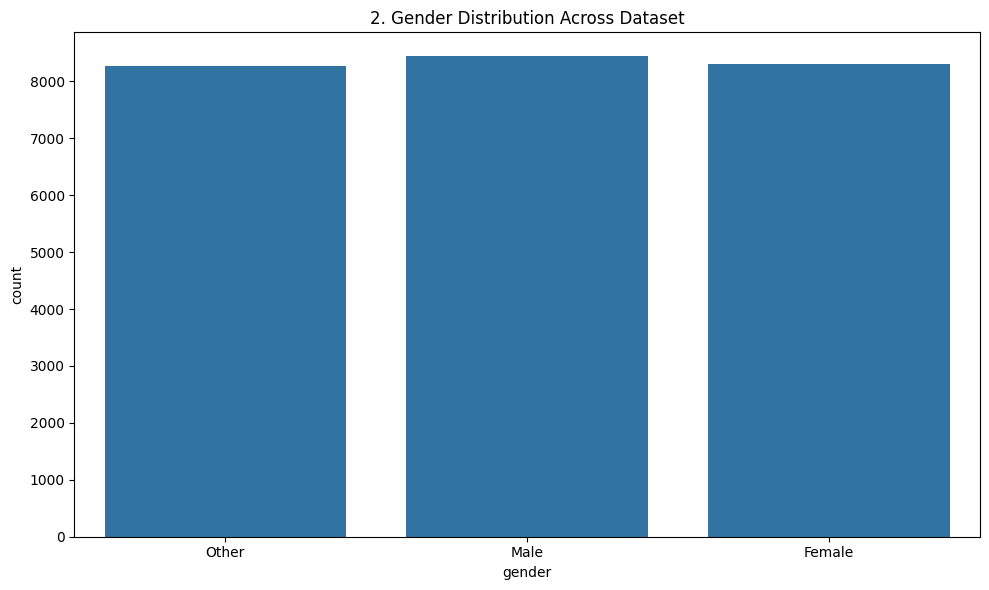

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='gender', data=df)
plt.title(f'{plot_no}. Gender Distribution Across Dataset')
show_fig()
plot_no += 1

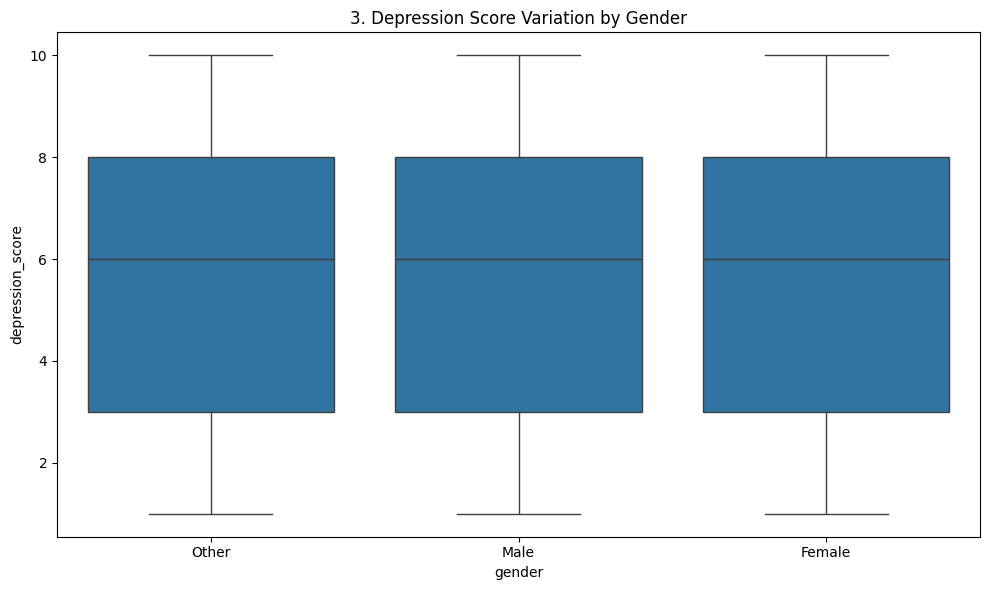

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='depression_score', data=df)
plt.title(f'{plot_no}. Depression Score Variation by Gender')
show_fig()
plot_no += 1

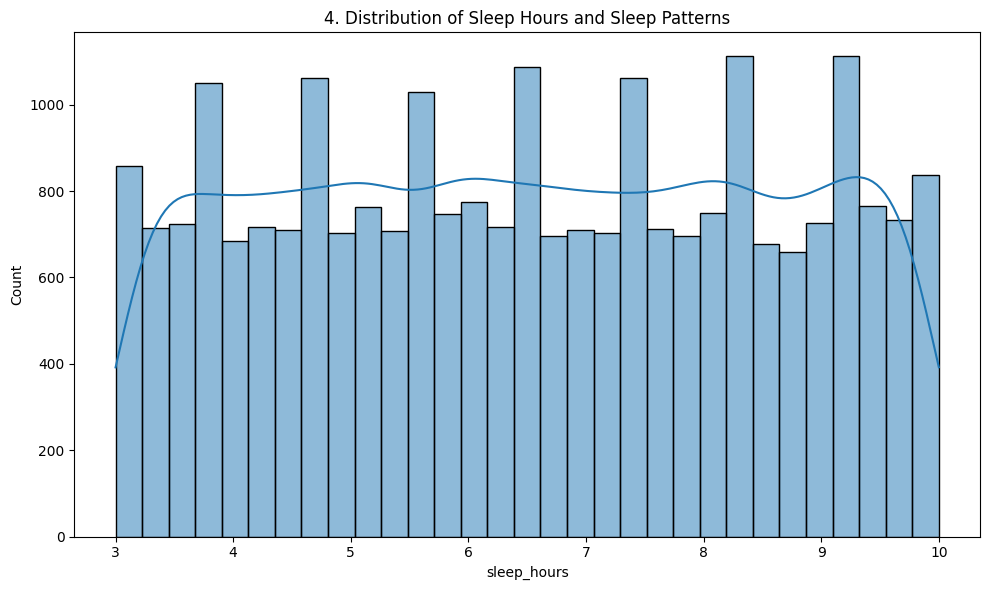

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['sleep_hours'], kde=True)
plt.title(f'{plot_no}. Distribution of Sleep Hours and Sleep Patterns')
show_fig()
plot_no += 1

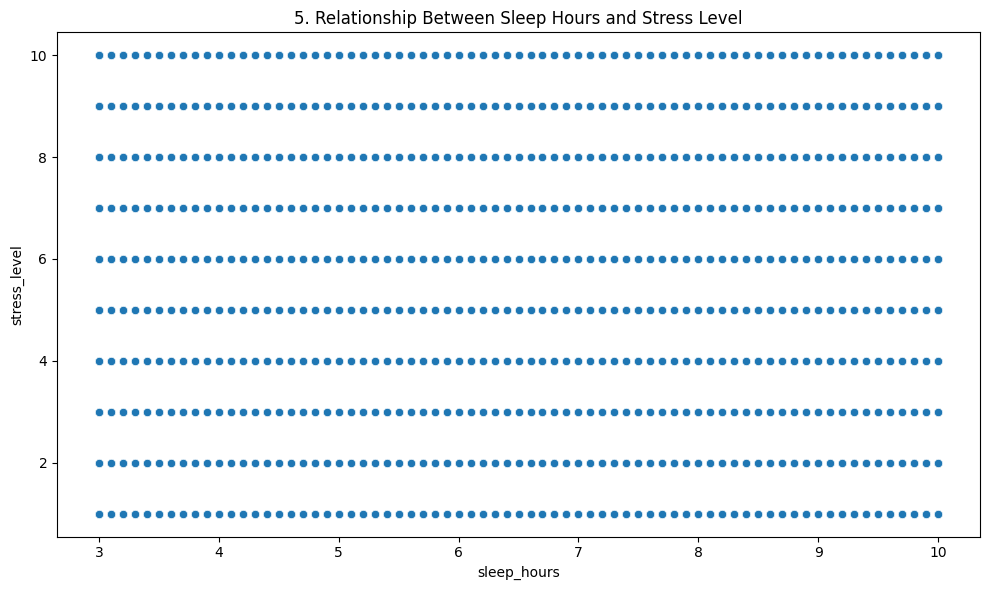

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='sleep_hours', y='stress_level', data=df)
plt.title(f'{plot_no}. Relationship Between Sleep Hours and Stress Level')
show_fig()
plot_no += 1

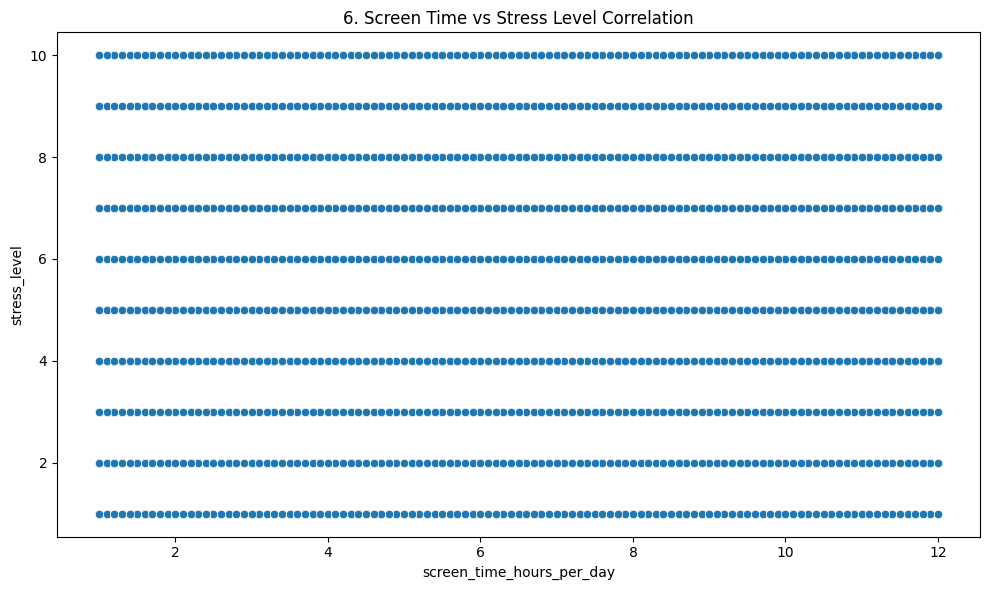

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='screen_time_hours_per_day', y='stress_level', data=df)
plt.title(f'{plot_no}. Screen Time vs Stress Level Correlation')
show_fig()
plot_no += 1

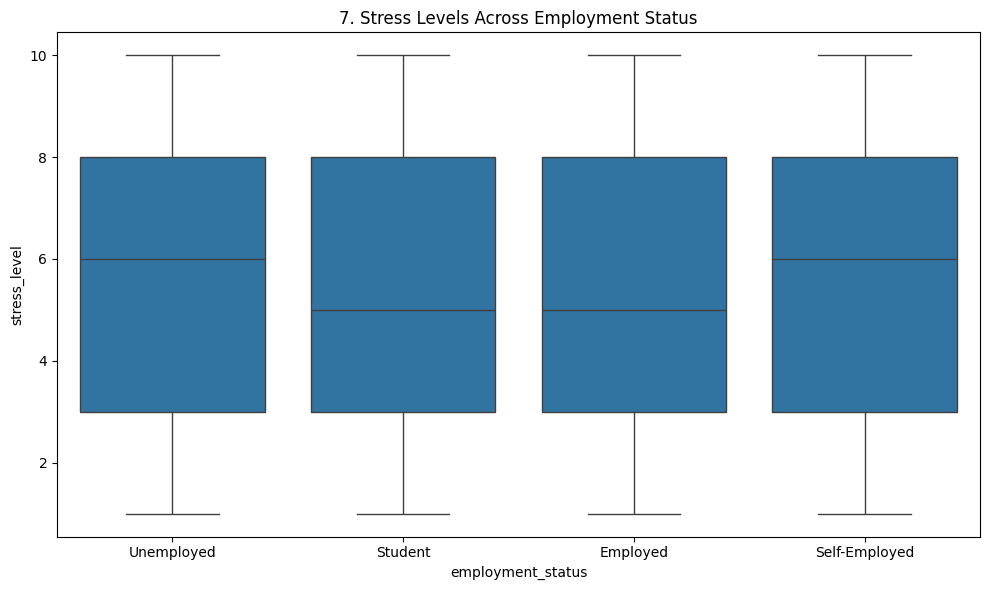

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='employment_status', y='stress_level', data=df)
plt.title(f'{plot_no}. Stress Levels Across Employment Status')
show_fig()
plot_no += 1

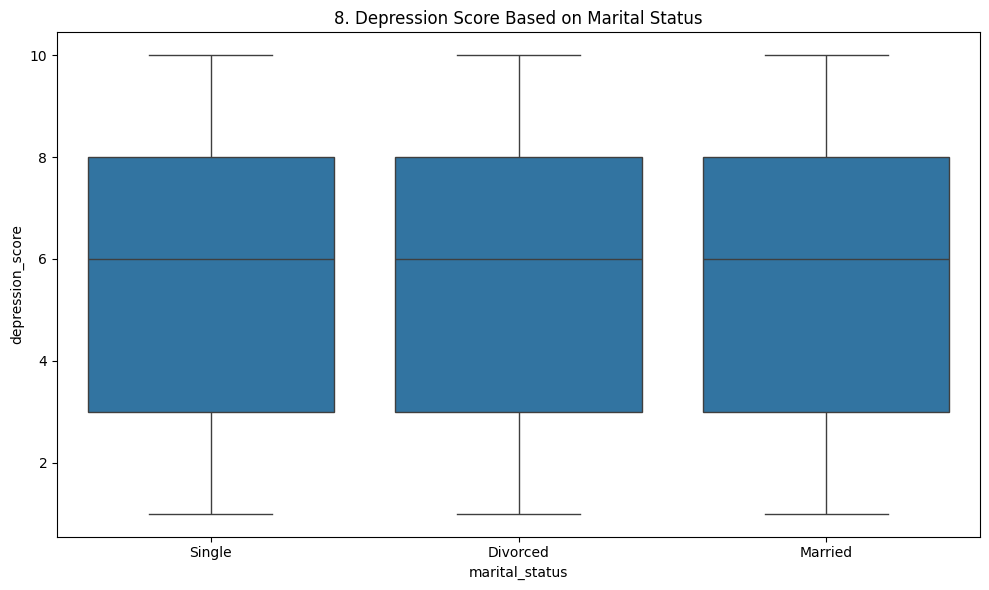

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='marital_status', y='depression_score', data=df)
plt.title(f'{plot_no}. Depression Score Based on Marital Status')
show_fig()
plot_no += 1

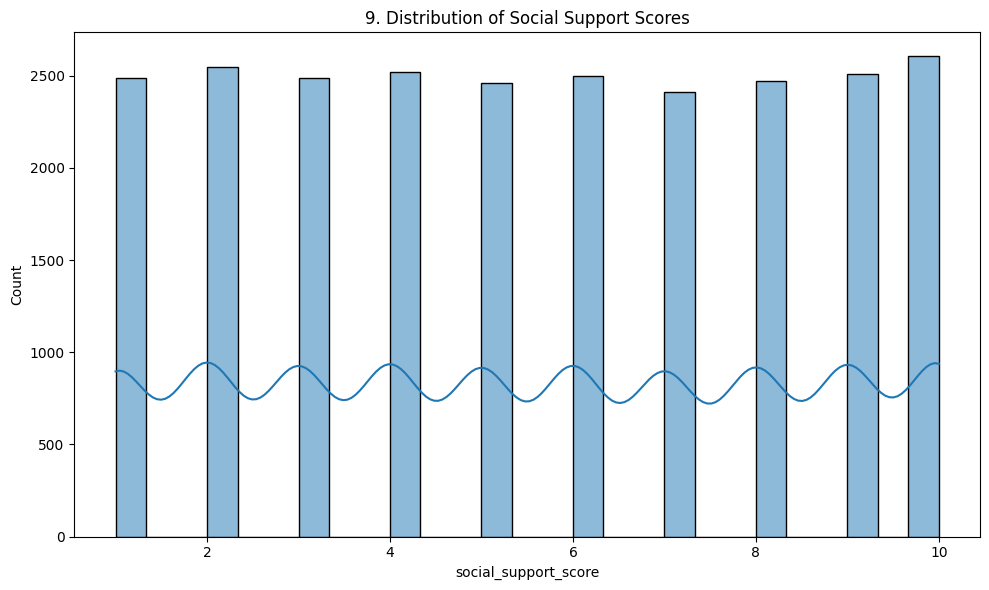

In [21]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['social_support_score'], kde=True)
plt.title(f'{plot_no}. Distribution of Social Support Scores')
show_fig()
plot_no += 1

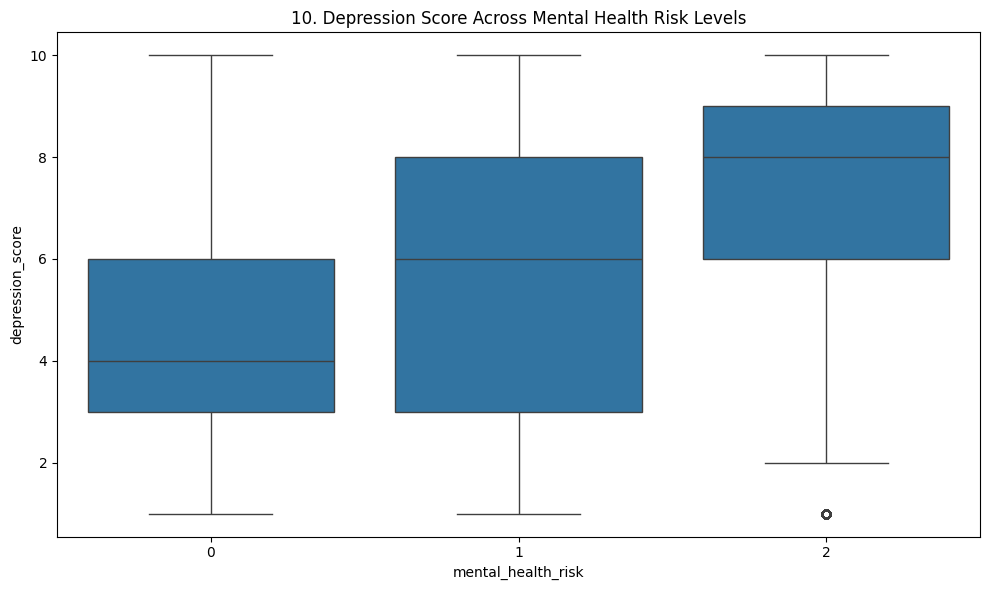

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='mental_health_risk', y='depression_score', data=df)
plt.title(f'{plot_no}. Depression Score Across Mental Health Risk Levels')
show_fig()
plot_no += 1

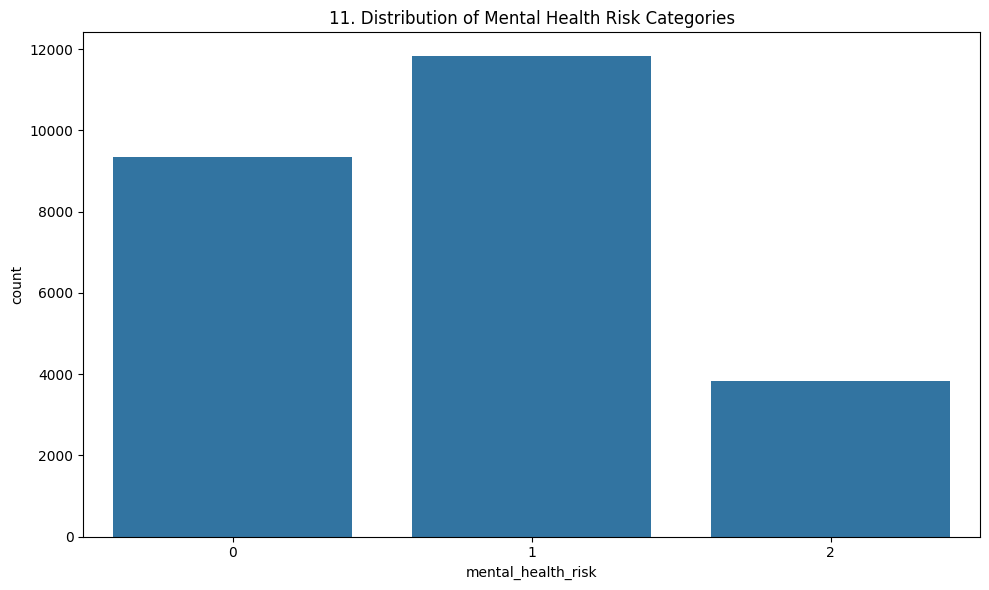

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='mental_health_risk', data=df)
plt.title(f'{plot_no}. Distribution of Mental Health Risk Categories')
show_fig()
plot_no += 1

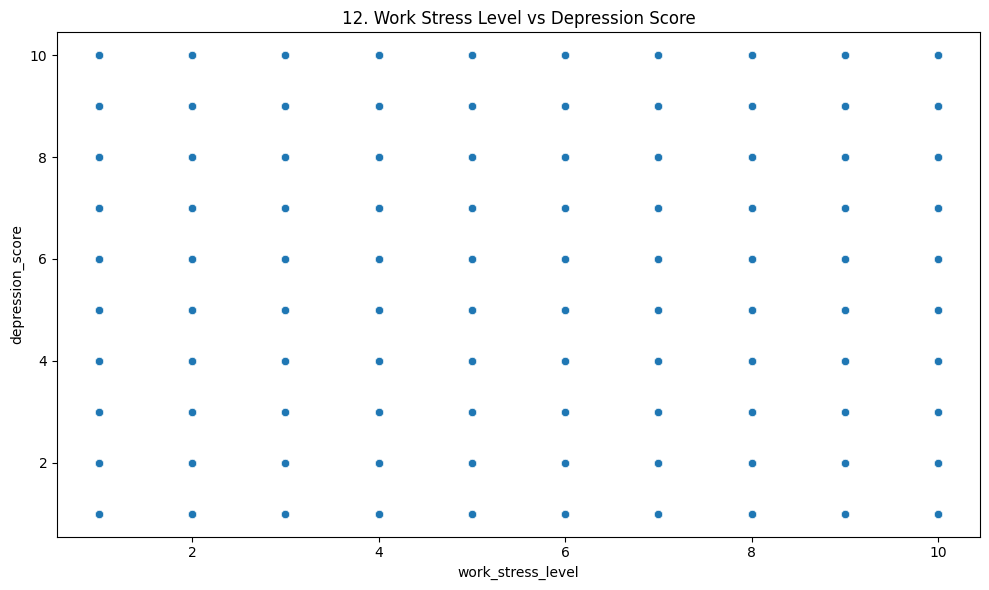

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='work_stress_level', y='depression_score', data=df)
plt.title(f'{plot_no}. Work Stress Level vs Depression Score')
show_fig()
plot_no += 1

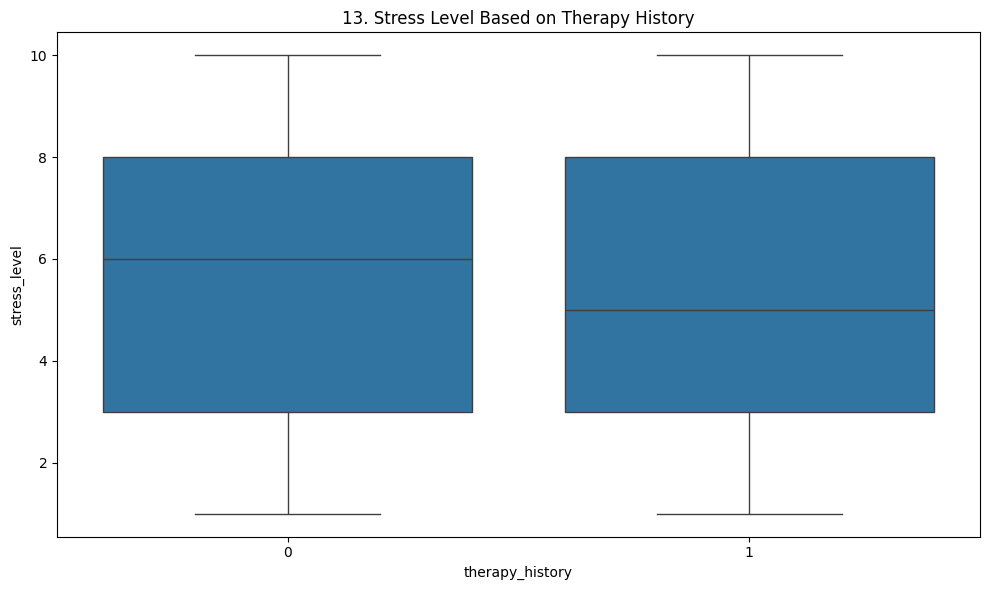

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='therapy_history', y='stress_level', data=df)
plt.title(f'{plot_no}. Stress Level Based on Therapy History')
show_fig()
plot_no += 1

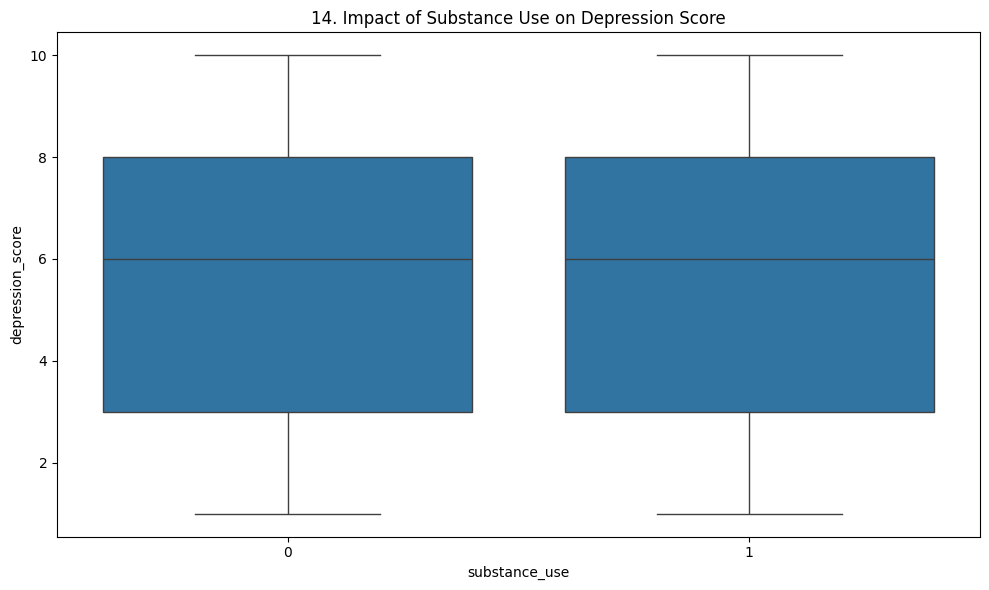

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='substance_use', y='depression_score', data=df)
plt.title(f'{plot_no}. Impact of Substance Use on Depression Score')
show_fig()
plot_no += 1

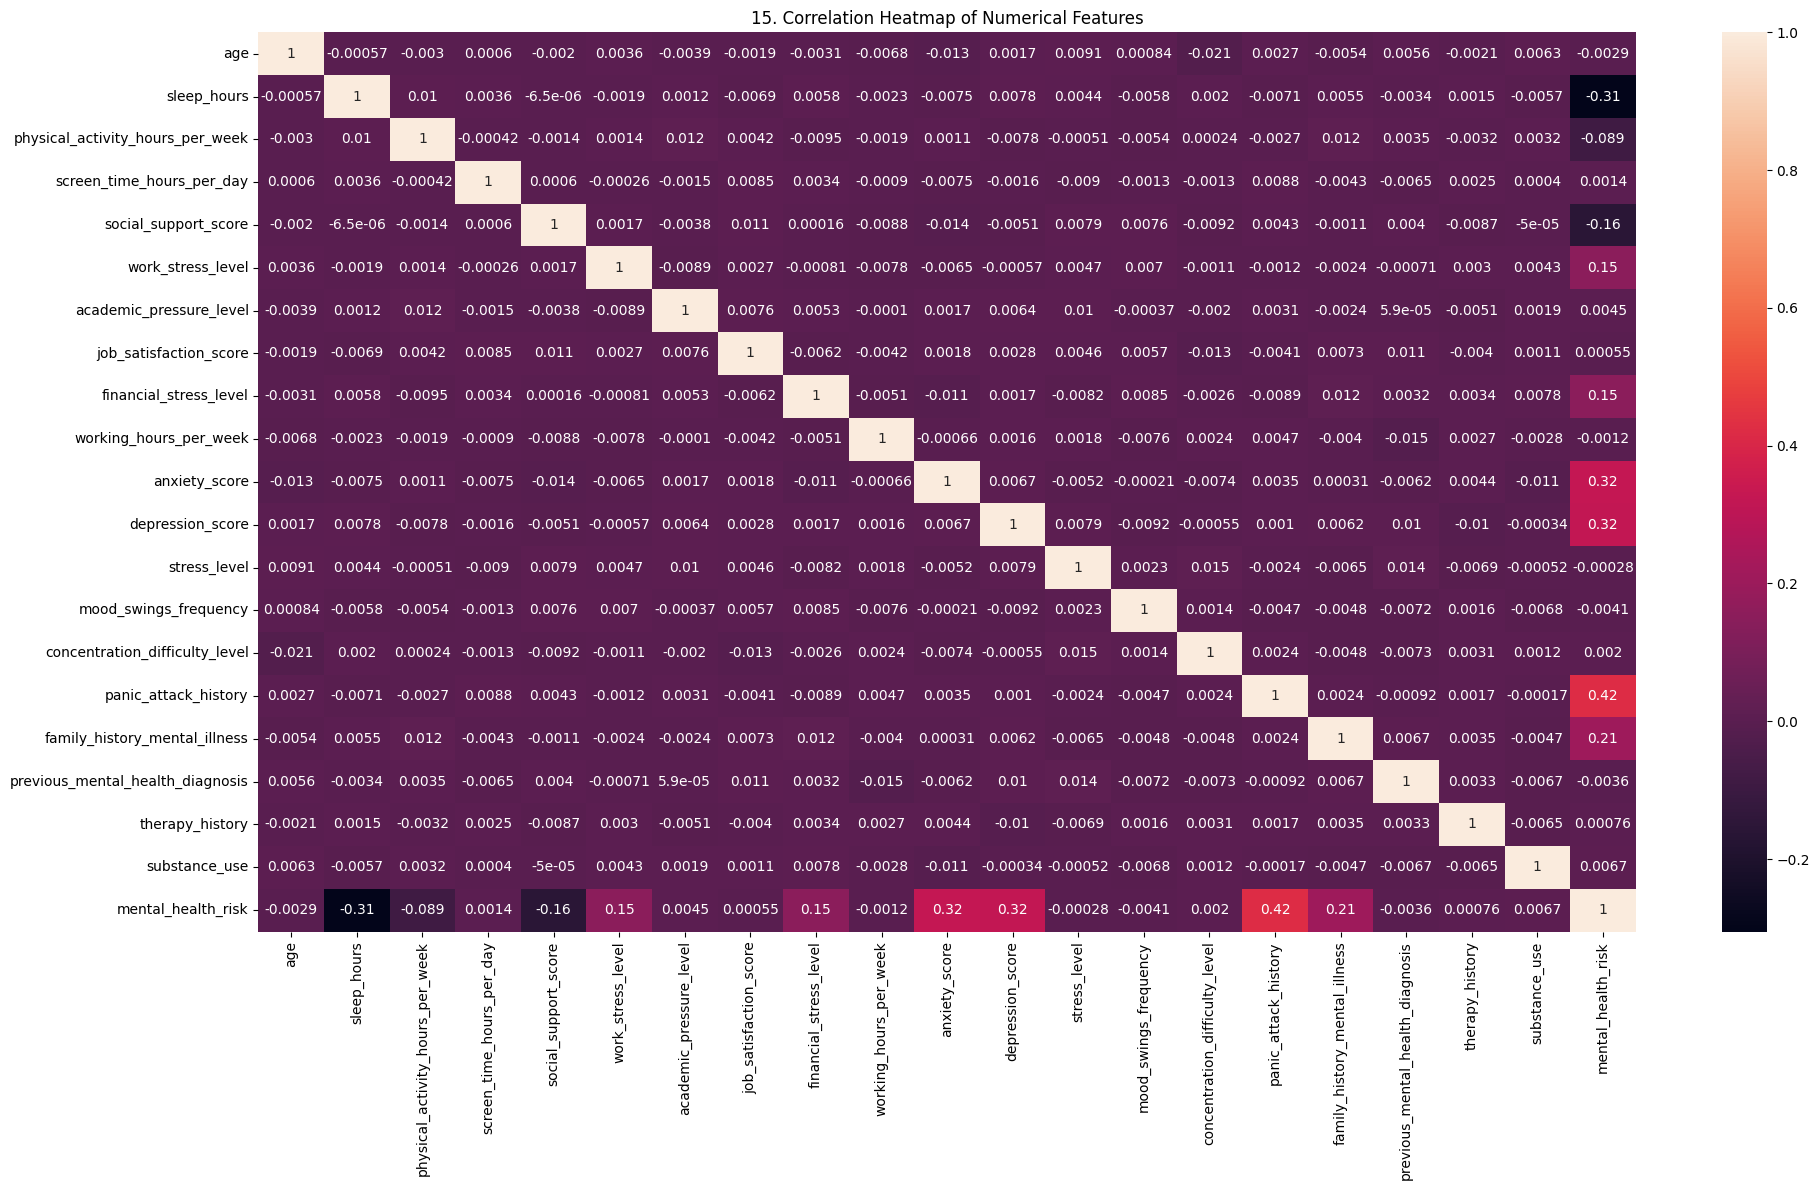

In [27]:
fig = plt.figure(figsize=(20, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

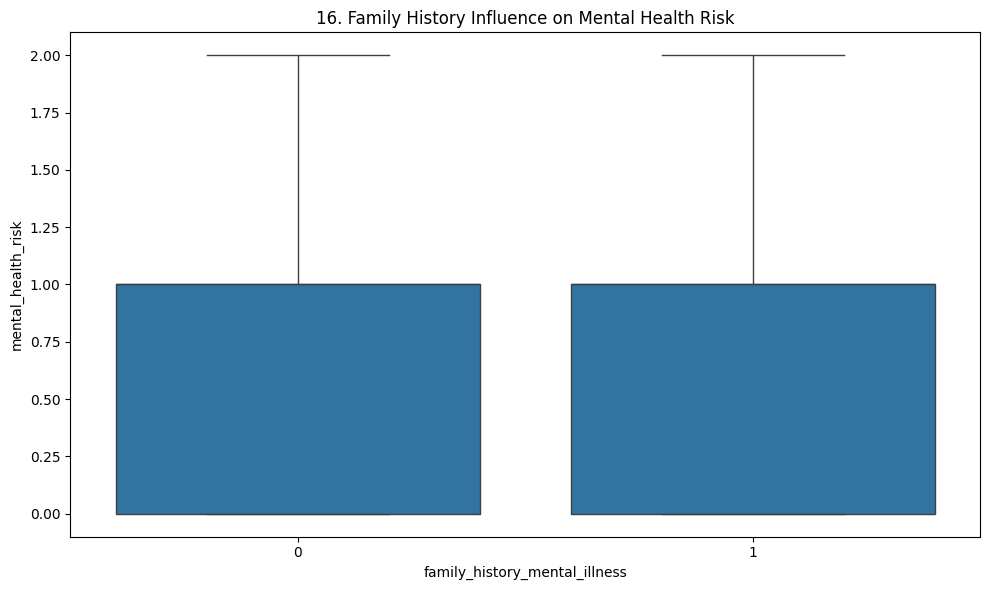

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='family_history_mental_illness', y='mental_health_risk', data=df)
plt.title(f'{plot_no}. Family History Influence on Mental Health Risk')
show_fig()
plot_no += 1

# Model Training

## separate features and target

In [29]:
X = df.drop('mental_health_risk', axis=1)
y = df['mental_health_risk']

# identify categorical and numerical columns

In [30]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

## preprocessing: scaling + encoding

In [31]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## define base models

In [32]:
base_models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svc', SVC(probability=True)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

## stacking classifier (advanced ensemble)

In [33]:
model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)

## full pipeline

In [34]:
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', model)
])

## split dataset

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## train model

In [36]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'sleep_hours', 'physical_activity_hours_per_week',
       'screen_time_hours_per_day', 'social_support_score',
       'work_stress_level', 'academic_pressure_level',
       'job_satisfaction_score', 'financial_stress_level',
       'working_hours_per_week', 'anxiety_score', 'depression_sc...
       'therapy_history', 'substance_use'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'marital_status', 'education_level', 'employment_status'], dtype='object'))])),
                ('model',
                 StackingClassifier(cv=5,
                                    estimators=[('lr',
                                                 LogisticRegression(max_iter=1000)),
                                                ('svc', SVC(probability=True)),
                                                ('knn',
                                                 KNeighborsClassifier())],
                                    final_estimator=LogisticRegression()))])

## predictions

In [37]:
y_pred = pipeline.predict(X_test)

## accuracy score

In [38]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy Score:", acc)

Accuracy Score: 0.823


## confusion matrix

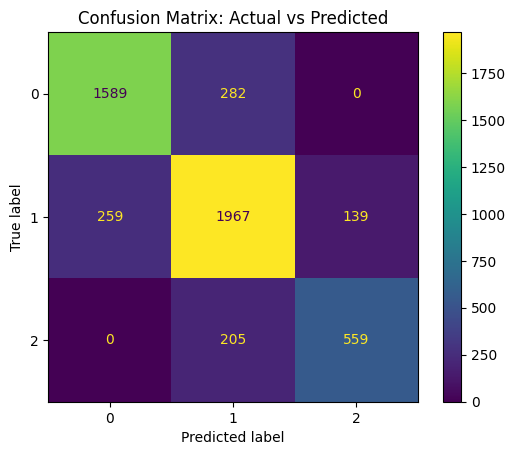

In [39]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix: Actual vs Predicted")
plt.show()